In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the cleaned data
df = pd.read_csv('~/dashboardData_v2_cleaned.csv')

In [3]:
df.shape

(444772, 117)

In [4]:
# Target variable distribution
print("READMISSION value counts:")
print(df['READMISSION'].value_counts())
print("\nPercentages:")
print(df['READMISSION'].value_counts(normalize=True) * 100)

READMISSION value counts:
READMISSION
0    376818
1     67954
Name: count, dtype: int64

Percentages:
READMISSION
0    84.72161
1    15.27839
Name: proportion, dtype: float64


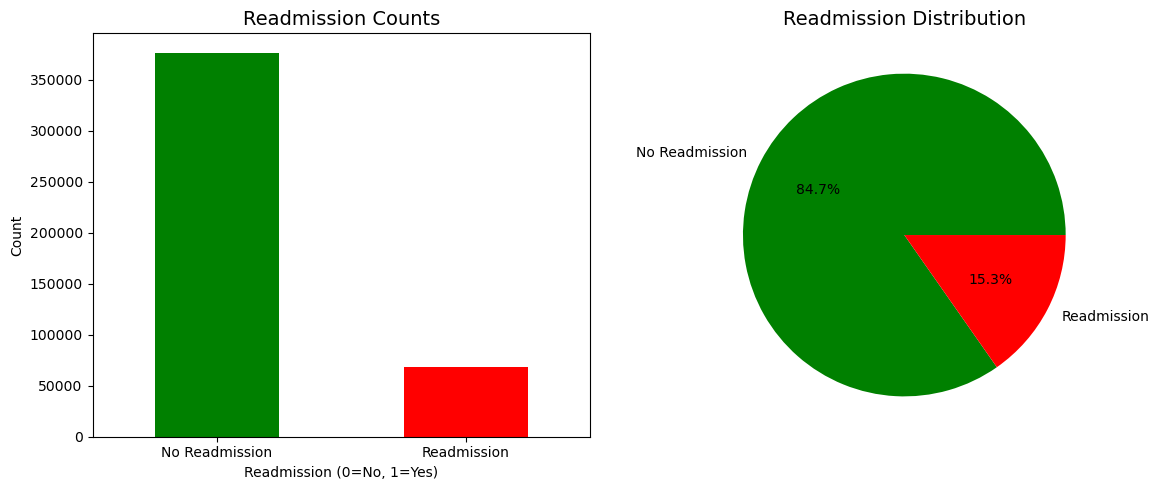

In [5]:
# Visualize target distribution
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
df['READMISSION'].value_counts().plot(kind='bar', ax=ax[0], color=['green', 'red'])
ax[0].set_title('Readmission Counts', fontsize=14)
ax[0].set_xlabel('Readmission (0=No, 1=Yes)')
ax[0].set_ylabel('Count')
ax[0].set_xticklabels(['No Readmission', 'Readmission'], rotation=0)

# Pie chart
df['READMISSION'].value_counts().plot(kind='pie', ax=ax[1], autopct='%1.1f%%', 
                                       labels=['No Readmission', 'Readmission'],
                                       colors=['green', 'red'])
ax[1].set_ylabel('')
ax[1].set_title('Readmission Distribution', fontsize=14)

plt.tight_layout()
plt.show()

In [6]:
# Create correlation matrix
corr_matrix = df.corr()

# Find high correlations (excluding diagonal)
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) >= 0.95:  # threshold for "too correlated"
            high_corr_pairs.append({
                'feature1': corr_matrix.columns[i],
                'feature2': corr_matrix.columns[j],
                'correlation': corr_matrix.iloc[i, j]
            })

print(f"Found {len(high_corr_pairs)} feature pairs with |correlation| >= 0.95:")
for pair in high_corr_pairs:
    print(f"{pair['feature1']} <-> {pair['feature2']}: {pair['correlation']:.3f}")

Found 11 feature pairs with |correlation| >= 0.95:
is_heart_failure <-> is_renal_failure: 0.964
POPPCT_URB <-> POPPCT_RUR: -1.000
ACS_PCT_HH_CELLULAR <-> ACS_PCT_HH_INTERNET: 0.951
ACS_PCT_HH_INTERNET <-> ACS_PCT_HH_NO_INTERNET: -0.950
ACS_PCT_HEALTH_INC_138_199 <-> ACS_PCT_PERSON_INC_125_199: 0.975
ACS_PCT_HEALTH_INC_ABOVE400 <-> ACS_PCT_PERSON_INC_ABOVE200: 0.956
ACS_PCT_HEALTH_INC_BELOW137 <-> ACS_PCT_PERSON_INC_ABOVE200: -0.969
ACS_PCT_HEALTH_INC_BELOW137 <-> ACS_PCT_PERSON_INC_BELOW99: 0.977
ACS_PCT_HH_FOOD_STMP_BLW_POV <-> ACS_PCT_HH_PUB_ASSIST: 0.977
ACS_PCT_NONVET_POV_18_64 <-> ACS_PCT_PERSON_INC_BELOW99: 0.970
ByDiscipline_PT <-> ByDiscipline_RN: -0.953


In [7]:
print("Readmission rate by discipline:\n")
for col in ['ByDiscipline_RN', 'ByDiscipline_PT', 'ByDiscipline_OT', 'ByDiscipline_SLP/ST']:
    discipline_readmit = df[df[col]==1]['READMISSION'].mean()
    print(f"{col}: {discipline_readmit*100:.2f}% readmission rate")

overall_readmit = df['READMISSION'].mean()
print(f"\nOverall: {overall_readmit*100:.2f}% readmission rate")

Readmission rate by discipline:

ByDiscipline_RN: 16.27% readmission rate
ByDiscipline_PT: 3.16% readmission rate
ByDiscipline_OT: 1.66% readmission rate
ByDiscipline_SLP/ST: 1.62% readmission rate

Overall: 15.28% readmission rate


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Data structure
print(f"Dataset shape: {df.shape}")
print(f"Target variable (READMISSION) distribution:\n{df['READMISSION'].value_counts()}")

Dataset shape: (444772, 117)
Target variable (READMISSION) distribution:
READMISSION
0    376818
1     67954
Name: count, dtype: int64


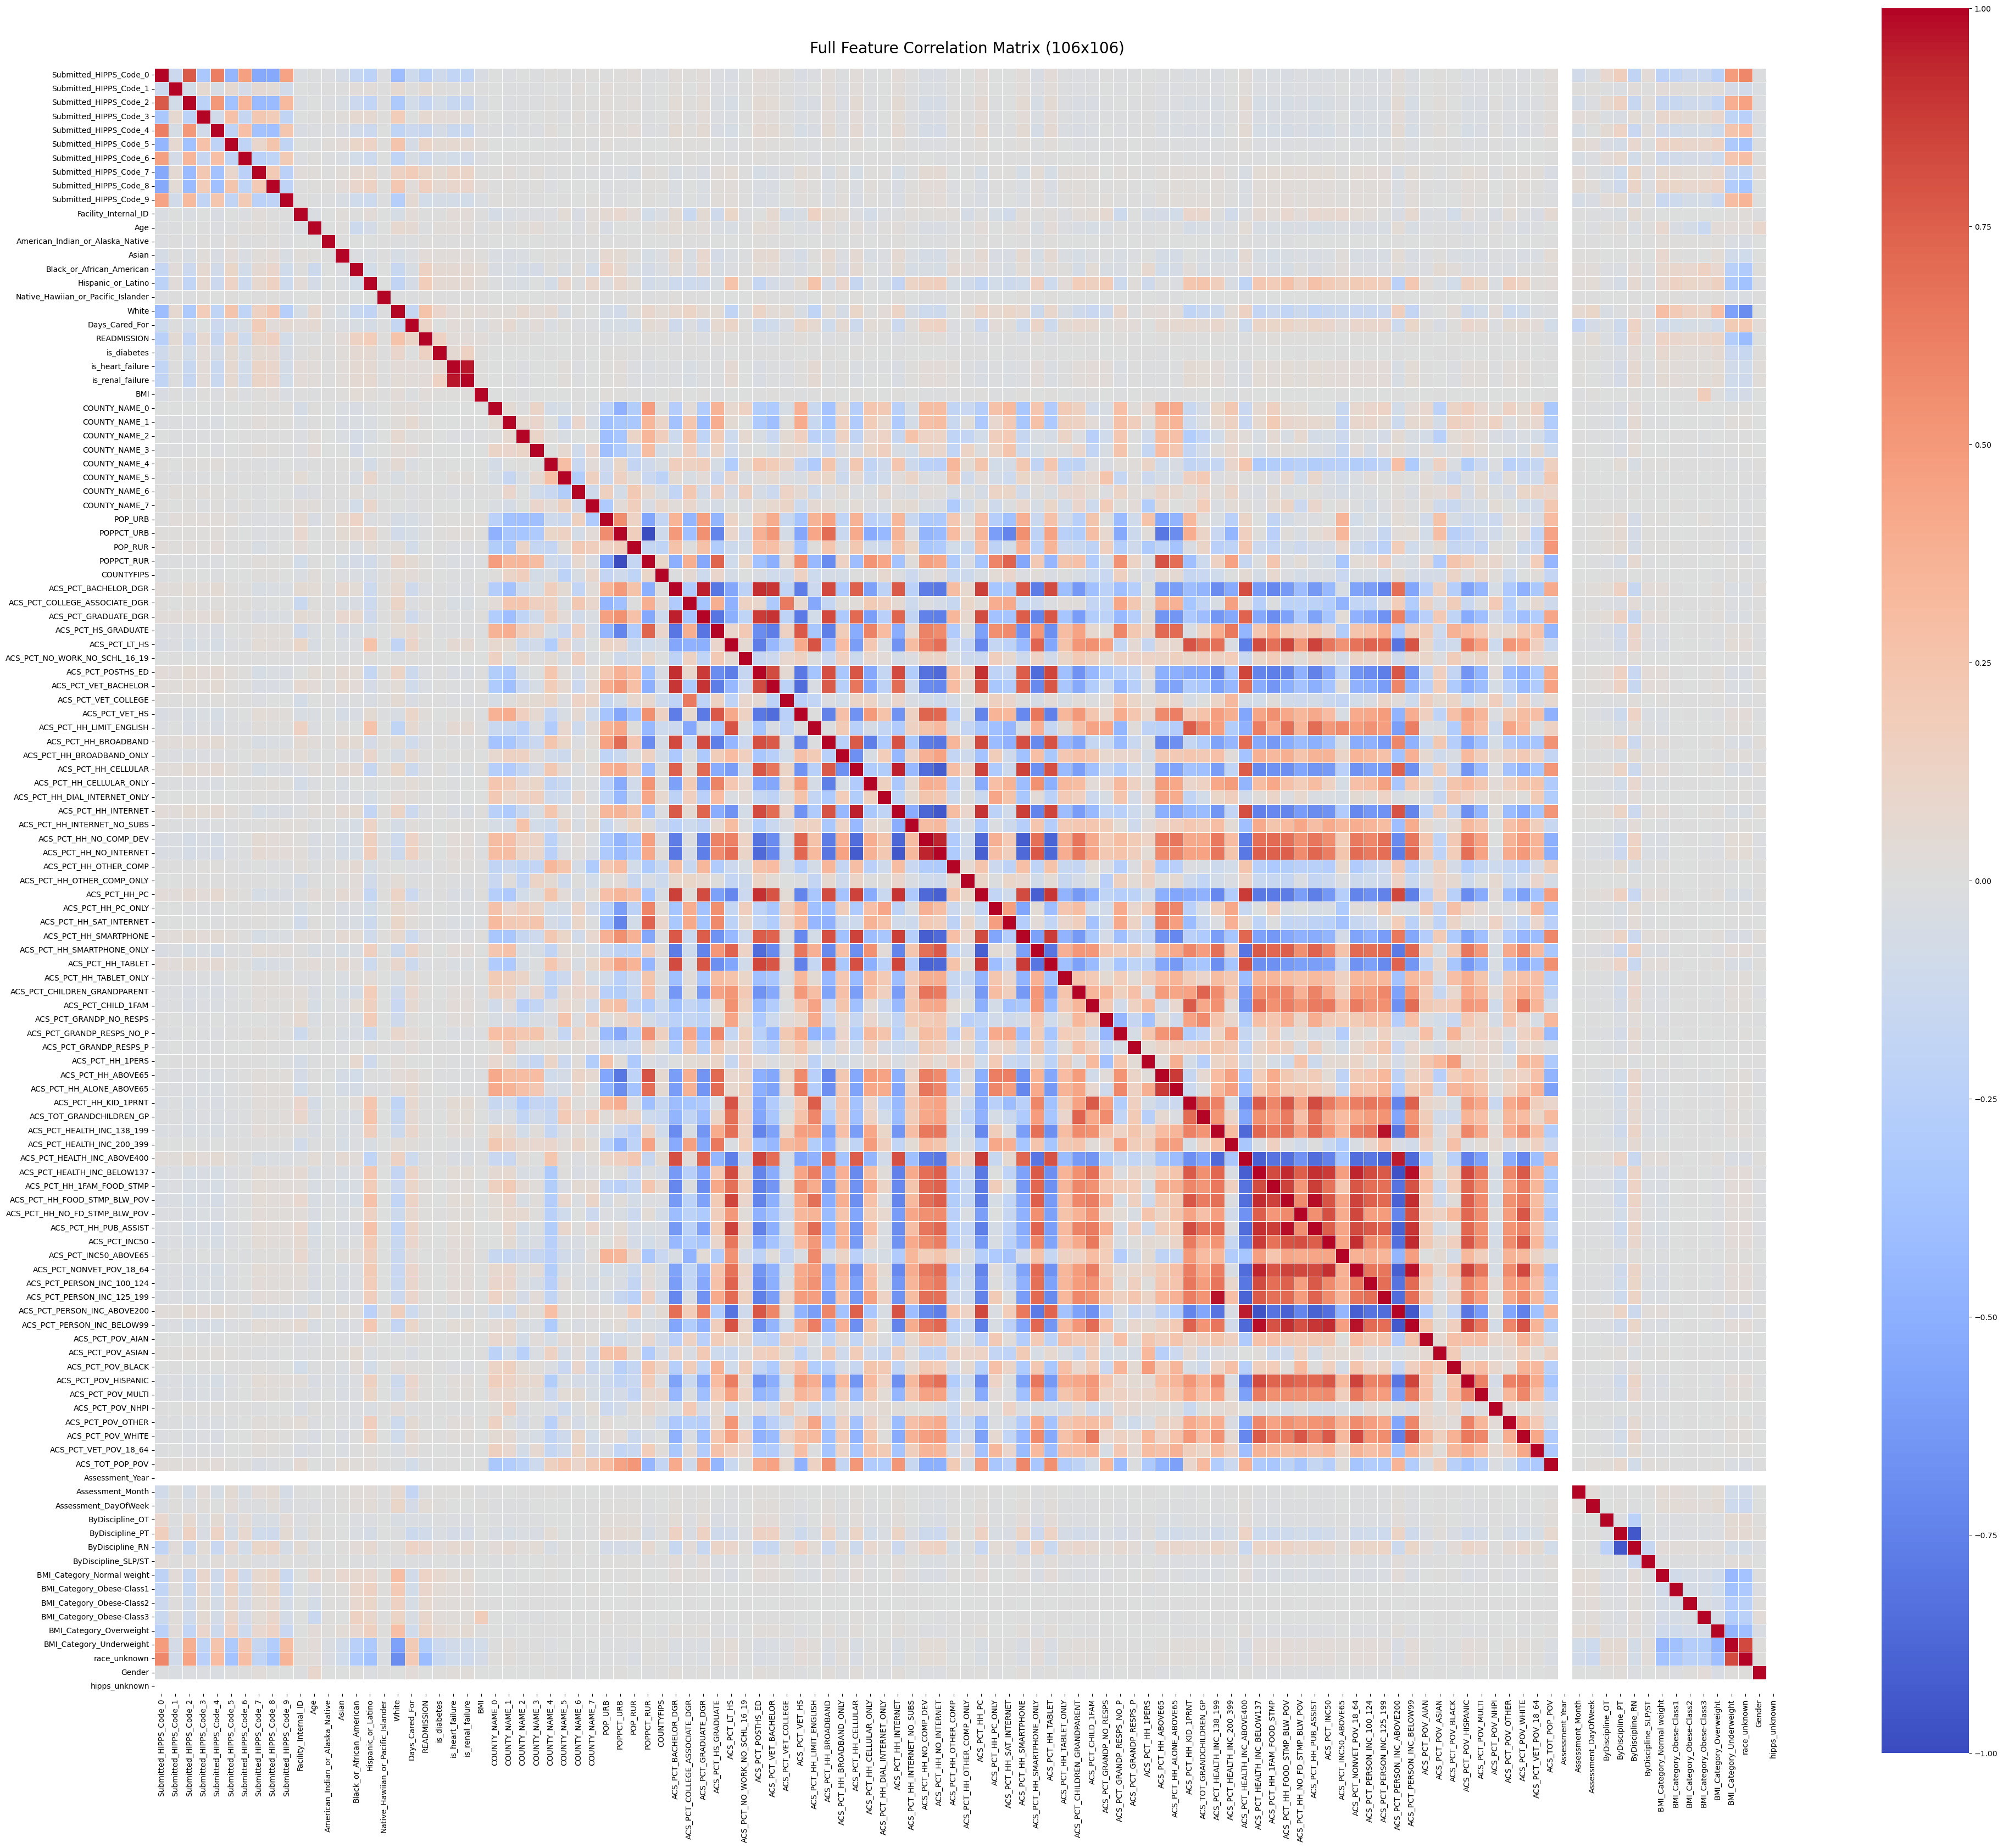

In [9]:
# Heat Map
corr_matrix = df.corr()

# Create figure
plt.figure(figsize=(40, 40)) 
sns.heatmap(corr_matrix, 
            cmap='coolwarm',  # Red = positive, Blue = negative
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8},
            annot=False)  # No numbers (would be unreadable)

plt.title('Full Feature Correlation Matrix (106x106)', fontsize=20, pad=20)
plt.tight_layout()
plt.show()


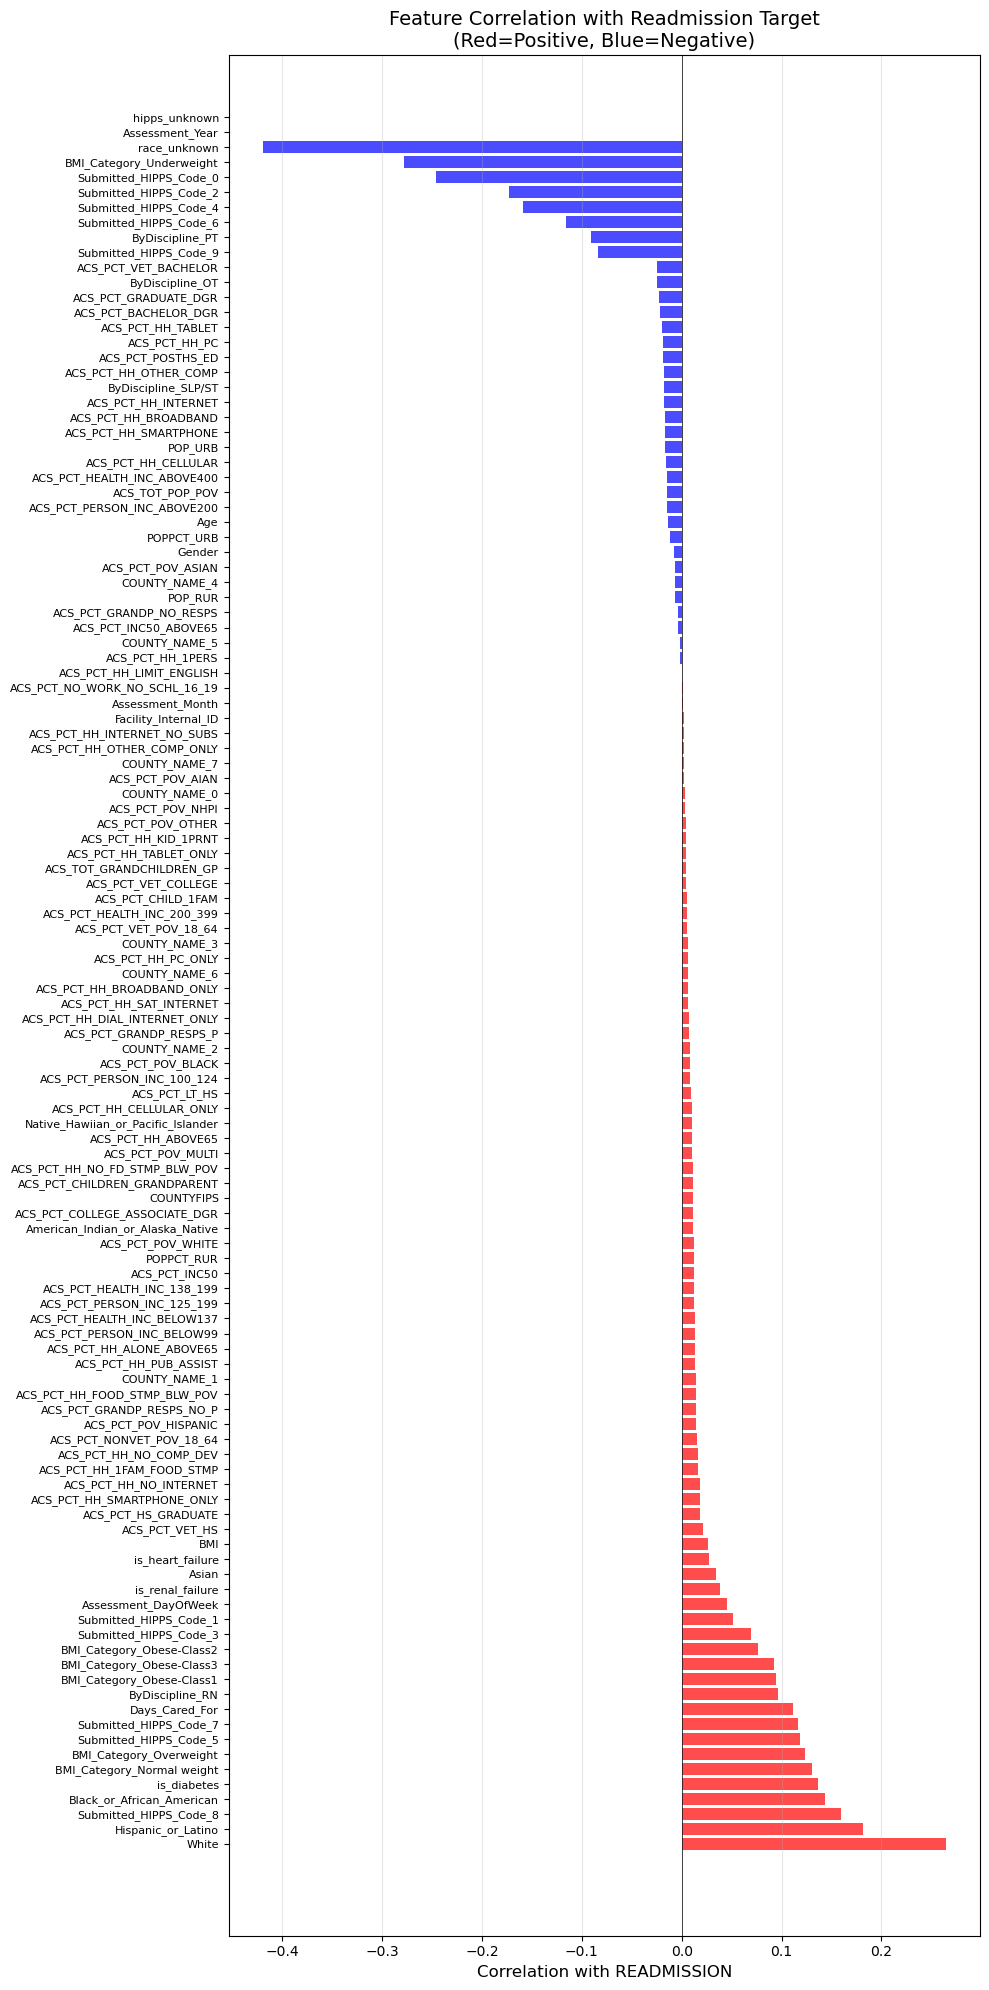

In [10]:
# Feature-to-Target Correlation
# Get correlations with READMISSION only
target_corr = corr_matrix['READMISSION'].drop('READMISSION').sort_values(ascending=False)
# Create figure
plt.figure(figsize=(10, 20))
colors = ['red' if x > 0 else 'blue' for x in target_corr.values]
plt.barh(range(len(target_corr)), target_corr.values, color=colors, alpha=0.7)
plt.yticks(range(len(target_corr)), target_corr.index, fontsize=8)
plt.xlabel('Correlation with READMISSION', fontsize=12)
plt.title('Feature Correlation with Readmission Target\n(Red=Positive, Blue=Negative)', fontsize=14)
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
print(target_corr.head(10)) #Positive Corr

White                         0.264440
Hispanic_or_Latino            0.181698
Submitted_HIPPS_Code_8        0.159945
Black_or_African_American     0.143493
is_diabetes                   0.136400
BMI_Category_Normal weight    0.130174
BMI_Category_Overweight       0.123828
Submitted_HIPPS_Code_5        0.118634
Submitted_HIPPS_Code_7        0.116437
Days_Cared_For                0.111550
Name: READMISSION, dtype: float64


In [12]:
print(target_corr.tail(10)) #Negative Corr

Submitted_HIPPS_Code_9     -0.083944
ByDiscipline_PT            -0.091185
Submitted_HIPPS_Code_6     -0.116196
Submitted_HIPPS_Code_4     -0.158605
Submitted_HIPPS_Code_2     -0.172914
Submitted_HIPPS_Code_0     -0.246202
BMI_Category_Underweight   -0.278191
race_unknown               -0.419521
Assessment_Year                  NaN
hipps_unknown                    NaN
Name: READMISSION, dtype: float64
